# Baseline Model — MobileNetV2 (No Augmentation)

## Purpose

This notebook trains a **baseline image classification model** using transfer learning with MobileNetV2. The goal is to establish a reference accuracy score that future experiments (e.g. with data augmentation or fine-tuning strategies) can be compared against.

The preprocessing pipeline is imported directly from `src/preprocessing.py`, keeping this notebook focused purely on model architecture, training, and evaluation.

---

## What this notebook covers

| Step | Description |
|------|-------------|
| 1. Setup & Imports | Libraries and dataset loading via `src.preprocessing` |
| 2. Load Data | Call `get_datasets()` and verify split sizes |
| 3. Build Model | Pretrained MobileNetV2 base + custom classification head |
| 4. Compile | Loss function, optimiser, and evaluation metrics |
| 5. Train | `model.fit()` with early stopping and model checkpointing |
| 6. Evaluate | Compare best and last saved models on the test set |
| 7. Training Curves | Accuracy and loss plots over epochs |
| 8. Misclassified Images | Visualise images the model got wrong |

---

## What is a baseline model?

A baseline is the simplest reasonable version of a model — trained with no data augmentation, default hyperparameters, and minimal tuning. It answers the question: *how well does the model perform out of the box?*

Any future improvement (augmentation, learning rate schedules, unfreezing layers) will be judged against this score.

---

## Why MobileNetV2?

MobileNetV2 is a lightweight convolutional neural network designed for mobile and embedded devices. It was pretrained on ImageNet (1.4 million images, 1000 classes), giving it strong general-purpose visual features. Key reasons for choosing it:

- **Accuracy vs. size trade-off** — competitive accuracy at a fraction of the size of larger models like ResNet or EfficientNet
- **Core ML compatible** — converts directly to Core ML for on-device inference on iPhone
- **Transfer learning friendly** — pretrained weights generalise well to custom datasets with limited data

## 1. Setup & Imports

This section imports all required libraries and loads the preprocessing pipeline from `src/preprocessing.py`.

### Path setup

Notebooks run from the `notebooks/` directory, but `src/preprocessing.py` lives one level up in the project root. Adding the project root to `sys.path` allows Python to find the `src` package when we write `from src.preprocessing import ...`.

### Constants

All image constants (`IMAGE_SIZE`, `BATCH_SIZE`, `RANDOM_SEED`) are defined in `src/preprocessing.py` and imported here to keep everything consistent across notebooks — there is no need to redefine them.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
# tf.config.set_visible_devices([], 'GPU')

# Add the project root to sys.path so 'from src.preprocessing import ...' works
sys.path.insert(0, str(Path().resolve().parent))

from src.preprocessing import (get_datasets, IMAGE_SIZE, BATCH_SIZE, RANDOM_SEED)

print("Image size:        ", IMAGE_SIZE)
print("Batch size:        ", BATCH_SIZE)
print("Random seed:       ", RANDOM_SEED)

Image size:         (224, 224)
Batch size:         32
Random seed:        42


## 2. Load Data

This section calls `get_datasets()` from `src/preprocessing.py` which runs the full pipeline — scanning the dataset folder, splitting into train/val/test, and building `tf.data` pipelines — in a single call.

The number of batches per split is printed as a sanity check to confirm the data loaded correctly before building the model.

In [2]:
train_ds, val_ds, test_ds, class_names = get_datasets()

NUM_CLASSES = len(class_names)

print(f"Classes ({NUM_CLASSES}):      {class_names}")
print(f"Train batches:     {len(train_ds)}")
print(f"Validation batches:{len(val_ds)}")
print(f"Test batches:      {len(test_ds)}")

Classes (8):      ['2', '3', '4', '5', '7', '8', '9', '10']
Train batches:     27
Validation batches:6
Test batches:      6


2026-04-09 23:58:40.483024: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-04-09 23:58:40.483046: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-04-09 23:58:40.483052: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-04-09 23:58:40.483066: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-09 23:58:40.483078: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 3. Build Model

### Transfer learning strategy

The model is built in two parts:

**1. MobileNetV2 base (frozen)**
MobileNetV2 pretrained on ImageNet is loaded without its original classification head (`include_top=False`). All base layers are **frozen** — their weights will not be updated during training. This preserves the general visual features learned from 1.4 million ImageNet images and significantly reduces training time.

**2. Custom classification head**
A small set of new layers is added on top of the frozen base to adapt it to our 8-class building classification task:

| Layer | Output shape | Purpose |
|-------|-------------|---------|
| MobileNetV2 base | (7, 7, 1280) | Extracts visual features |
| GlobalAveragePooling2D | (1280,) | Reduces spatial dimensions to a single feature vector |
| Dropout(0.2) | (1280,) | Randomly disables 20% of neurons to reduce overfitting |
| Dense(8, softmax) | (8,) | Outputs a probability for each building class |

### Why GlobalAveragePooling2D instead of Flatten?

`Flatten` would produce a vector of 7 × 7 × 1280 = 62,720 values, leading to a very large number of parameters in the final layer. `GlobalAveragePooling2D` averages each feature map into a single value, producing a compact 1280-dimensional vector with far fewer parameters — better suited for a small dataset.

In [3]:
# Load MobileNetV2 pretrained on ImageNet, without the top classification layer
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze all base layers — their weights will not change during training
base_model.trainable = False

# Build the full model by adding a custom classification head
model = tf.keras.Sequential([
    base_model,
    # Average each 7x7 feature map into a single value → (1280,) vector
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        10,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,268,232 (8.65 MB)

 Trainable params: 10,248 (40.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 4. Compile

Before training, the model needs to be configured with three things:

**Loss function — `sparse_categorical_crossentropy`**
Used for multi-class classification where labels are integers (0–7). 

**Optimiser — `Adam(learning_rate=1e-3)`**
Adam is the standard choice for transfer learning. A learning rate of `1e-3` (0.001) is the default.

**Metric — `accuracy`**

In [4]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

## 5. Train

### Callbacks

Three behaviours are controlled via callbacks:

**Early stopping**
Monitors `val_loss` after each epoch. If it does not improve for **5 consecutive epochs** (`patience=5`), training stops automatically. `restore_best_weights=True` rolls the model back to the epoch with the lowest `val_loss` — not the last epoch.

**ModelCheckpoint — best model**
Saves the model to `models/baseline_mobilenetv2_best.keras` every time `val_loss` improves. This file always contains the best weights seen during training.

**Last model**
After `model.fit()` completes, the current model state is saved to `models/baseline_mobilenetv2_last.keras`. Combined with `restore_best_weights=True`, this will be identical to the best model — but keeping it as a separate file makes it easy to compare against future experiments where early stopping may behave differently.

### What to expect

Since the base is frozen and only the small classification head is being trained, each epoch will be fast. Validation accuracy should climb quickly in the first few epochs then plateau.

In [5]:
MODELS_DIR = Path().resolve().parent / "models"
MODELS_DIR.mkdir(exist_ok=True)

# Stop training early if val_loss does not improve for 5 consecutive epochs
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True  # Roll back to the best epoch when stopping
)

# Save the best model seen during training (lowest val_loss)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(MODELS_DIR / "baseline_mobilenetv2_best.keras"),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping, checkpoint]
)

# Save the final model state at the end of training (for comparison with best)
model.save(MODELS_DIR / "baseline_mobilenetv2_last.keras")
print("Last model saved to:", MODELS_DIR / "baseline_mobilenetv2_last.keras")

Epoch 1/30


2026-04-09 23:58:41.938323: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.2154 - loss: 2.2040
Epoch 1: val_loss improved from None to 1.27422, saving model to /Users/adamnajajreh/ltu/2. semester/DL/Capstone/models/baseline_mobilenetv2_best.keras

Epoch 1: finished saving model to /Users/adamnajajreh/ltu/2. semester/DL/Capstone/models/baseline_mobilenetv2_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.2905 - loss: 1.9344 - val_accuracy: 0.5815 - val_loss: 1.2742
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 955ms/step - accuracy: 0.6286 - loss: 1.1938
Epoch 2: val_loss improved from 1.27422 to 0.85980, saving model to /Users/adamnajajreh/ltu/2. semester/DL/Capstone/models/baseline_mobilenetv2_best.keras

Epoch 2: finished saving model to /Users/adamnajajreh/ltu/2. semester/DL/Capstone/models/baseline_mobilenetv2_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.6628 - loss: 1.0894 - val_accuracy: 0.7446 - val_loss: 0.8598
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 991ms/step - accu

## 6. Evaluate

This section evaluates both saved models on the **test set** — the held-out split that was never seen during training or validation.

- **Best model** (`baseline_mobilenetv2_best.keras`) — saved at the epoch with the lowest `val_loss`
- **Last model** (`baseline_mobilenetv2_last.keras`) — saved at the end of training

Comparing the two tells us whether early stopping and `restore_best_weights` made a meaningful difference. If their scores are identical, the best and last epoch were the same. If the best scores higher, the model had started to overfit by the final epoch.

Test accuracy is the final unbiased measure of how well the model generalises to new images and serves as the **baseline score** for all future experiments.

In [6]:
saved_models = {
    "Best  (lowest val_loss)": MODELS_DIR / "baseline_mobilenetv2_best.keras",
    "Last  (end of training)": MODELS_DIR / "baseline_mobilenetv2_last.keras",
}

print(f"{'Model':<30} {'Loss':>8}  {'Accuracy':>10}")
print("-" * 52)

for label, model_path in saved_models.items():
    loaded_model = tf.keras.models.load_model(model_path)
    loss, acc = loaded_model.evaluate(test_ds, verbose=0)
    print(f"{label:<30} {loss:>8.4f}  {acc * 100:>9.2f}%")

Model                              Loss    Accuracy
----------------------------------------------------
Best  (lowest val_loss)          0.2260      94.02%
Last  (end of training)          0.2260      94.02%


## 7. Training Curves

Plotting the training and validation accuracy and loss over each epoch gives a clear picture of how the model learned and whether it overfit.

**Accuracy plot** — both train and val accuracy should rise. If train accuracy keeps rising while val accuracy plateaus or drops, the model is overfitting.

**Loss plot** — both train and val loss should fall. A rising val loss while train loss continues to fall is the clearest sign of overfitting — this is exactly what early stopping monitors.

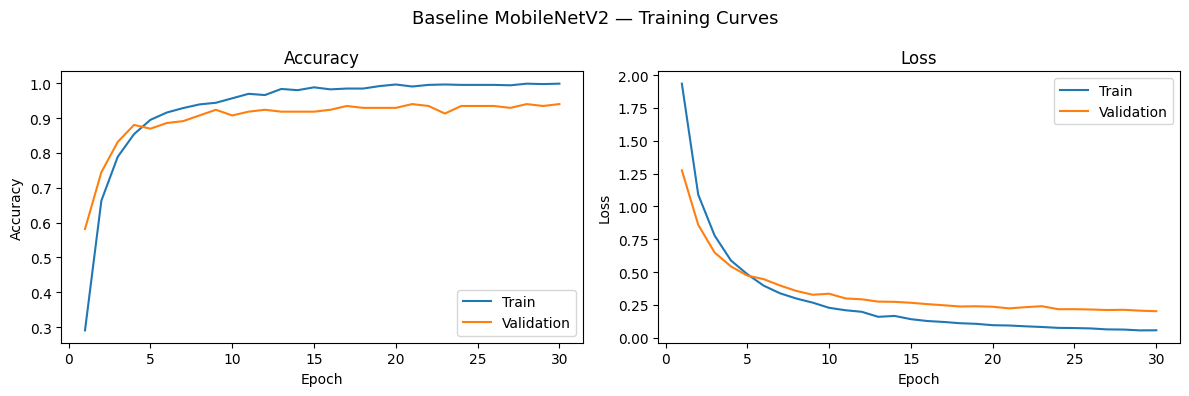

In [7]:
epochs_range = range(1, len(history.history["accuracy"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
ax1.plot(epochs_range, history.history["accuracy"],     label="Train")
ax1.plot(epochs_range, history.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

# Loss
ax2.plot(epochs_range, history.history["loss"],     label="Train")
ax2.plot(epochs_range, history.history["val_loss"], label="Validation")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.suptitle("Baseline MobileNetV2 — Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Misclassified Images

Visualising the images the model got wrong helps identify patterns in its mistakes — for example, which buildings are being confused with each other, and whether the errors come from difficult angles, lighting, or visual similarity between classes.

Loading model: baseline_mobilenetv2_best


2026-04-10 00:24:16.801498: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Total images:         184
Correctly classified: 173
Misclassified:        11
Accuracy:             94.02%


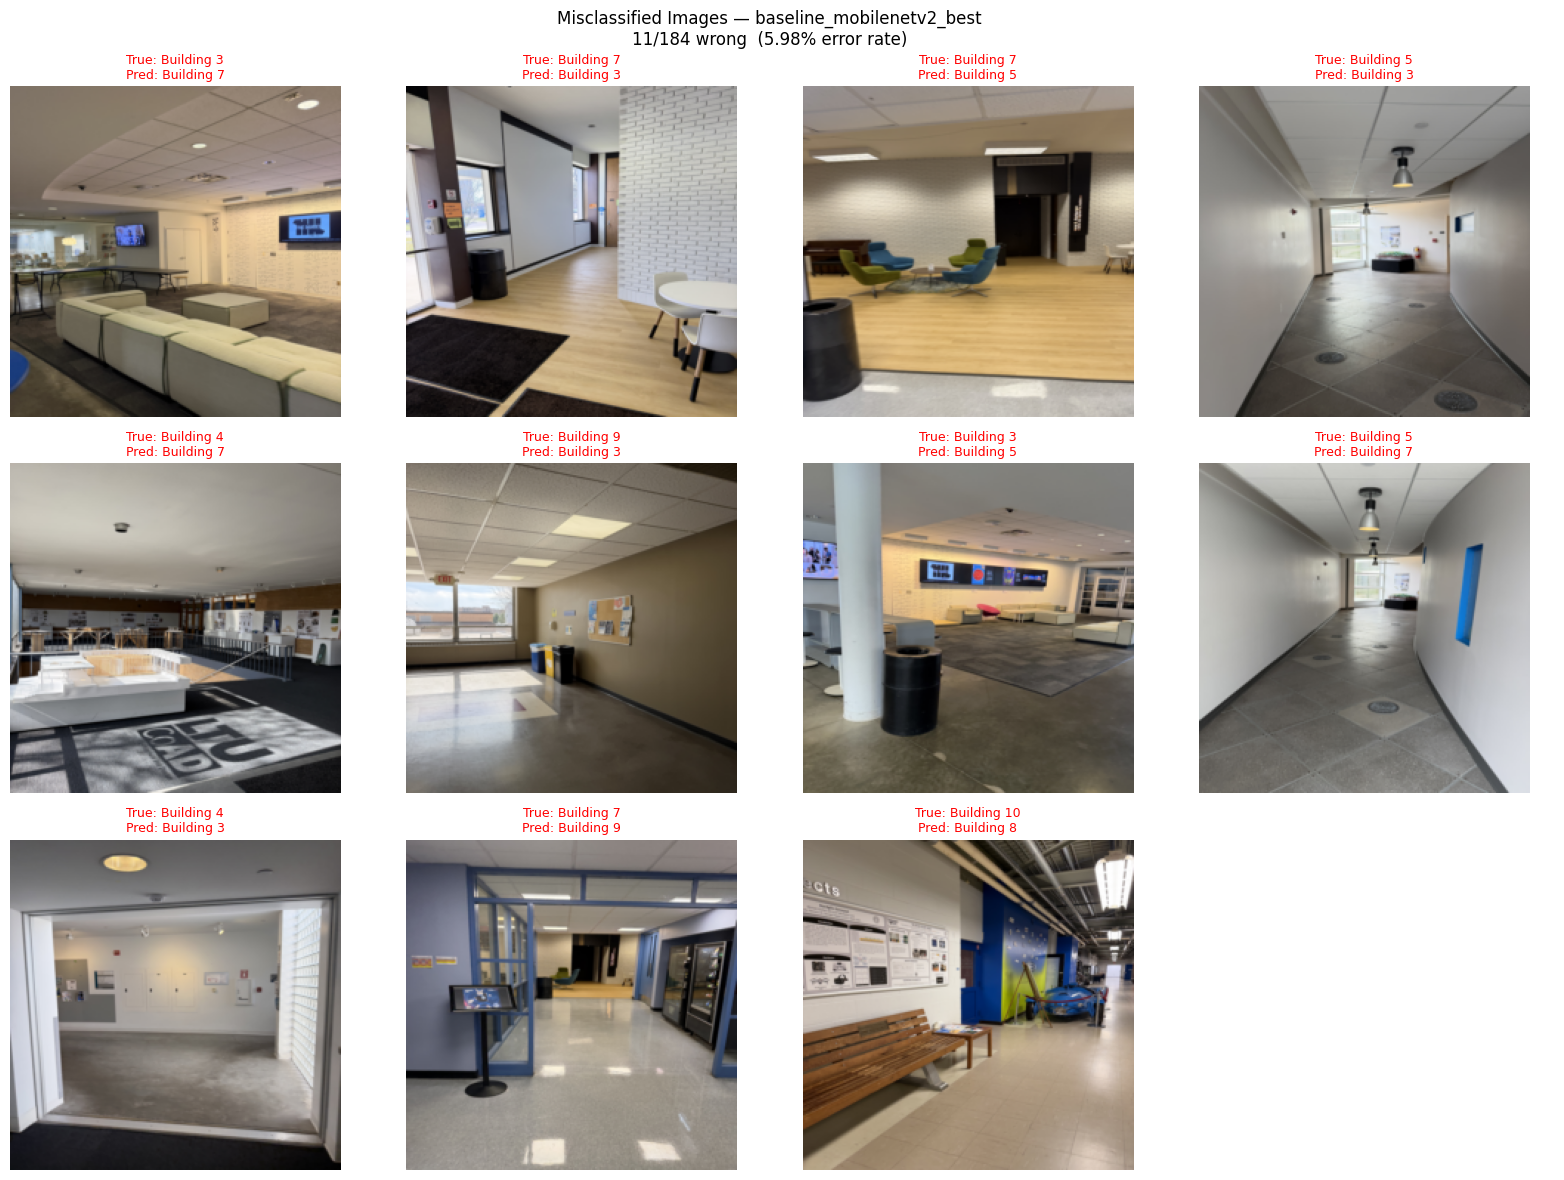

In [8]:
from src.visualize import show_misclassified

show_misclassified("baseline_mobilenetv2_best", test_ds, class_names)